In [1]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_mistralai import ChatMistralAI
from langchain_core.messages import SystemMessage, HumanMessage

In [3]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [ ]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0,
    api_key=""
)

response = llm.invoke("Hi")

print(response)

content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'EnEKbwERTTIPVs85JT/VePIx+vKwC8a6VXZD9vfE0am1GCiyr8B6WDYc8q7jpx7Az5CNno/j8/Se+LuB6mL2jwrDbsBHYXlPNtvUF7TNimY2+WGHX7PgRngtDGOaV0eYAl2xdtjejL2GrEBM5ldwBLoH2g=='}}] additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--01a0882f-2c99-7ad3-9f11-80eb98848fad-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 2, 'output_tokens': 9, 'total_tokens': 11, 'input_token_details': {'cache_read': 0}}


In [ ]:
from langchain_openrouter import ChatOpenRouter

llm = ChatOpenRouter(
    model="nvidia/nemotron-3-ultra-550b-a55b:free",
    temperature=0,
    api_key="",
)
msgs = [
    SystemMessage(content="You are a helpful Coding assistant with AI name Jox."),  
    HumanMessage(content="Create a **production-quality, premium Apple-inspired Liquid Glassmorphism Login Page** as a **single self-contained HTML5 file**. Return **ONLY the complete HTML code**—no Markdown, explanations, external assets, frameworks, CDNs, or dependencies—with all CSS inside `<style>` and JavaScript inside `<script>`. Include branding/logo, heading, supporting text, username/email, password with accessible show/hide toggle, Remember Me, Forgot Password, Sign In, and optional Sign Up. Use translucent layered glass, blur with fallback, subtle gradients, soft borders/shadows, ambient CSS-only blurred orbs, refined typography, strong contrast, and restrained animations. Make it fully responsive from **360px to 1440px+** using Flexbox/Grid with no overflow, clipping, or poor mobile spacing. Implement polished hover/focus/active/disabled/error states, accessible keyboard navigation, labels/ARIA, inline validation, email/password validation, loading state with **“Signing in...”**, reduced-motion support, and touch-friendly controls. Do not implement fake authentication, hard-code/store credentials, or use localStorage for passwords; structure submission for real API integration. Use semantic HTML, autocomplete attributes, CSS variables/design tokens, clean maintainable code, `addEventListener`, and no inline event handlers. The final result should look like a **real premium SaaS authentication page**, not a generic template."),
]

response = llm.invoke(msgs)

print(response.content)

<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <meta name="description" content="Sign in to your account">
  <title>Sign In | Aura</title>
  <style>
    :root {
      --color-bg: #0a0a0f;
      --color-bg-elevated: #11111a;
      --color-surface: rgba(22, 22, 32, 0.72);
      --color-surface-hover: rgba(30, 30, 44, 0.8);
      --color-surface-active: rgba(38, 38, 52, 0.88);
      --color-border: rgba(255, 255, 255, 0.08);
      --color-border-hover: rgba(255, 255, 255, 0.14);
      --color-border-focus: #0066ff;
      --color-border-error: #ff453a;
      --color-text-primary: #ffffff;
      --color-text-secondary: rgba(255, 255, 255, 0.64);
      --color-text-tertiary: rgba(255, 255, 255, 0.4);
      --color-accent: #0066ff;
      --color-accent-hover: #0052cc;
      --color-accent-active: #004099;
      --color-accent-soft: rgba(0, 102, 255, 0.12);
      --color-error: #ff453a;
      --color-e

In [3]:
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv

load_dotenv(override=True)

llm = ChatMistralAI(
    model="mistral-small-latest",
    temperature=0,
)


print(llm.invoke("Hi").content)

HTTPStatusError: Error response 429 while fetching https://api.mistral.ai/v1/chat/completions: {"object":"error","message":"Rate limit exceeded","type":"rate_limited","param":null,"code":"1300","raw_status_code":429}

In [ ]:
from langchain_groq import ChatGroq

# Initialize the ChatGroq model with a Groq-hosted model name
llm = ChatGroq(
    model="minimaxai/minimax-m2.7",
    temperature=0.7,
    api_key=""
)

msgs = [
    SystemMessage(content="You are a helpful assistant with AI name Jox."),  
    HumanMessage(content="Give me the complete HTML code for Login page with username and password fields, and a submit button. Make it responsive and visually appealing. The Design style should be Liquid Glass design. Use modern design principles and best practices. Provide the code only, no explanations."),
]
# Invoke the chat model
response = llm.invoke(msgs)
print(response.content)

NotFoundError: Error code: 404 - {'error': {'message': 'The model `minimaxai/minimax-m2.7` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}

In [ ]:
import requests
import os

api_key = os.environ.get("")
url = "https://api.groq.com/openai/v1/models"

headers = {
    "Authorization": f"Bearer ",
    "Content-Type": "application/json"
}

response = requests.get(url, headers=headers)

response.json()

{'object': 'list',
 'data': [{'id': 'qwen/qwen3.8-27b',
   'object': 'model',
   'created': 1786984846,
   'owned_by': 'Alibaba Cloud',
   'active': True,
   'context_window': 131042,
   'public_apps': None,
   'max_completion_tokens': 16384,
   'name': 'Qwen/Qwen3.8-27B',
   'input_modalities': ['text', 'image'],
   'output_modalities': ['text'],
   'context_length': 131042,
   'max_output_length': 16384,
   'pricing': {'prompt': '0.0000008',
    'completion': '0.000004',
    'image': '0',
    'request': '0',
    'input_cache_read': '0.0000004'},
   'supported_sampling_parameters': ['temperature',
    'top_p',
    'stop',
    'seed',
    'max_tokens'],
   'supported_features': ['tools', 'json_mode', 'reasoning']},
  {'id': 'qwen/qwen3.6-27b',
   'object': 'model',
   'created': 1778288776,
   'owned_by': 'Alibaba Cloud',
   'active': True,
   'context_window': 131072,
   'public_apps': None,
   'max_completion_tokens': 16384,
   'hugging_face_id': 'Qwen/Qwen3.6-27B',
   'name': 'Qwen/

In [19]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [20]:
def fanout(state: State):
    return [
        Send(
            "worker", 
            {"task": task, "topic": state["topic"], "plan": state["plan"]}
            )
            for task in state["plan"].tasks
            ]

In [21]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [22]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")
    print(final_md)
    return {"final": final_md}


In [23]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

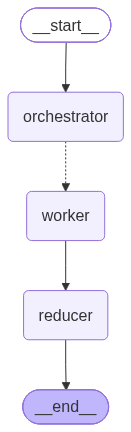

In [24]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [25]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})
# out = app.invoke({"topic": "Write a blog on Self Attention"})

# Understanding Self-Attention: The Core of Transformer Models

## Introduction to Self-Attention

Self-attention is a powerful mechanism in deep learning that allows a model to dynamically focus on different parts of its input when processing sequential data. Unlike traditional recurrence or convolution, self-attention directly computes relationships between all positions in a sequence, enabling it to capture long-range dependencies efficiently. Its introduction marked a paradigm shift in natural language processing (NLP), as it eliminated the need for recurrent or convolutional layers in many tasks.

At the heart of transformer models, self-attention enables parallel processing of sequences while maintaining contextual understanding. By assigning attention weights to each input element, the model learns to emphasize relevant tokens, improving performance in tasks like machine translation, text summarization, and sentiment analysis. This mechanism not only boosts accuracy but also enh

In [58]:
from typing import TypedDict, Annotated
import operator

from langgraph.graph import StateGraph, START, END


# ============================================================
# CLARIFICATION SUBGRAPH STATE
# ============================================================

class ClarificationState(TypedDict, total=False):
    requirements: str
    conversation_log: Annotated[list, operator.add]
    turn_count: int
    max_turns: int
    completeness: bool
    unresolved_gaps: list


# ============================================================
# GENERATION SUBGRAPH STATE
# ============================================================

class GenerationState(TypedDict, total=False):
    requirements: str
    unresolved_gaps: list

    outline: str
    section_drafts: Annotated[list, operator.add]
    diagram_specs: Annotated[list, operator.add]
    validated_diagrams: Annotated[list, operator.add]
    final_document: str


# ============================================================
# PARENT GRAPH STATE
# ============================================================

class ParentState(TypedDict, total=False):
    requirements: str
    unresolved_gaps: list
    final_document: str


# ============================================================
# 1. CLARIFICATION GRAPH
# ============================================================

clarification_builder = StateGraph(ClarificationState)


clarification_builder.add_node(
    "analyze_initial_requirements",
    lambda state: {}
)

clarification_builder.add_node(
    "check_completeness",
    lambda state: {}
)

clarification_builder.add_node(
    "ask_question",
    lambda state: {}
)

clarification_builder.add_node(
    "update_requirements",
    lambda state: {}
)


# START → analyze
clarification_builder.add_edge(
    START,
    "analyze_initial_requirements"
)

clarification_builder.add_edge(
    "analyze_initial_requirements",
    "check_completeness"
)


# completeness → question / finish
clarification_builder.add_conditional_edges(
    "check_completeness",
    lambda state: "complete",
    {
        "ask_question": "ask_question",
        "complete": END,
    }
)


# clarification loop
clarification_builder.add_edge(
    "ask_question",
    "update_requirements"
)

clarification_builder.add_edge(
    "update_requirements",
    "check_completeness"
)


# Compile independently
clarification_graph = clarification_builder.compile()


# ============================================================
# 2. GENERATION GRAPH
# ============================================================

generation_builder = StateGraph(GenerationState)


generation_builder.add_node(
    "generate_outline",
    lambda state: {}
)

generation_builder.add_node(
    "generate_sections",
    lambda state: {}
)

generation_builder.add_node(
    "generate_diagrams",
    lambda state: {}
)

generation_builder.add_node(
    "validate_diagrams",
    lambda state: {}
)

generation_builder.add_node(
    "assemble_document",
    lambda state: {}
)


generation_builder.add_edge(
    START,
    "generate_outline"
)

generation_builder.add_edge(
    "generate_outline",
    "generate_sections"
)

generation_builder.add_edge(
    "generate_sections",
    "generate_diagrams"
)

generation_builder.add_edge(
    "generate_diagrams",
    "validate_diagrams"
)


# Diagram repair loop
generation_builder.add_conditional_edges(
    "validate_diagrams",
    lambda state: "done",
    {
        "repair": "generate_diagrams",
        "done": "assemble_document",
    }
)

generation_builder.add_edge(
    "assemble_document",
    END
)


# Compile independently
generation_graph = generation_builder.compile()


# ============================================================
# 3. PARENT GRAPH
# ============================================================

parent_builder = StateGraph(ParentState)


# ------------------------------------------------------------
# run_clarification
# ------------------------------------------------------------

def run_clarification(state):
    result = clarification_graph.invoke({
        "requirements": state.get("requirements", ""),
        "conversation_log": [],
        "turn_count": 0,
        "max_turns": 5,
        "completeness": False,
        "unresolved_gaps": [],
    })

    return {
        "requirements": result.get("requirements", ""),
        "unresolved_gaps": result.get("unresolved_gaps", []),
    }


# ------------------------------------------------------------
# run_generation
# ------------------------------------------------------------

def run_generation(state):
    result = generation_graph.invoke({
        "requirements": state.get("requirements", ""),
        "unresolved_gaps": state.get("unresolved_gaps", []),
    })

    return {
        "final_document": result.get("final_document", "")
    }


parent_builder.add_node(
    "run_clarification",
    run_clarification
)

parent_builder.add_node(
    "run_generation",
    run_generation
)


# ============================================================
# PARENT GRAPH FLOW
# ============================================================

parent_builder.add_edge(
    START,
    "run_clarification"
)


parent_builder.add_conditional_edges(
    "run_clarification",
    lambda state: "run_generation",
    {
        "run_generation": "run_generation",
    }
)


parent_builder.add_edge(
    "run_generation",
    END
)


# ============================================================
# COMPILE PARENT GRAPH
# ============================================================

parent_graph = parent_builder.compile()


# ============================================================
# PRINT PARENT GRAPH
# ============================================================




# ============================================================
# PRINT CLARIFICATION SUBGRAPH
# ============================================================



# ============================================================
# PRINT GENERATION SUBGRAPH
# ============================================================




===== GENERATION GRAPH =====



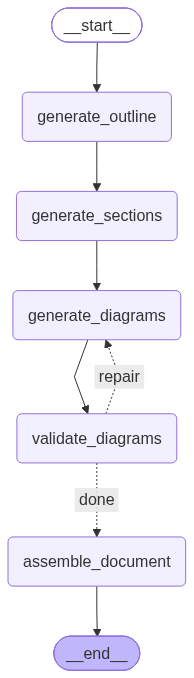

In [59]:
print("\n===== GENERATION GRAPH =====\n")
generation_graph


===== CLARIFICATION GRAPH =====



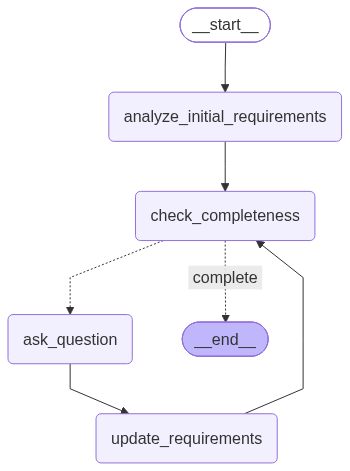

In [60]:
print("\n===== CLARIFICATION GRAPH =====\n")
clarification_graph



===== PARENT GRAPH =====



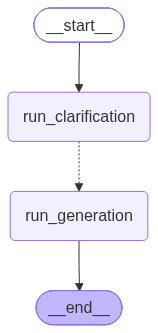

In [61]:
print("\n===== PARENT GRAPH =====\n")
parent_graph

In [86]:
lst = [{'type': 'text', 'text': "# 1.0 Introduction\n\nThis Software Requirements Specification (SRS) document defines the complete, authoritative functional, non-functional, and interface requirements for the Real-Time Ride-Hailing Platform. This document serves as the primary technical baseline for the engineering, quality assurance, and product operations teams.\n\n---\n\n## 1.1 Purpose\n\nThe purpose of this document is to establish a rigorous, unambiguous specification of the Real-Time Ride-Hailing Platform. It details the system's capabilities, performance characteristics, architectural constraints, and external interfaces. \n\nThis SRS is designed to:\n*   Provide a definitive guide for backend developers implementing the Python FastAPI and Redis services.\n*   Establish clear implementation boundaries for iOS and Android mobile client engineers.\n*   Define the verification criteria for Quality Assurance (QA) to validate system compliance.\n*   Serve as the contractually binding technical scope for stakeholders, administrators, and external integration partners (such as PCI-compliant Payment Gateways).\n\n---\n\n## 1.2 Scope\n\nThe Real-Time Ride-Hailing Platform is a highly scalable, low-latency, real-time ride-matching and dispatch system. The platform connects mobile riders requesting on-demand transportation with nearby, vetted, and active drivers. \n\n### 1.2.1 In-Scope System Capabilities\nThe software system encompasses the following core subsystems:\n1.  **Rider Mobile Application (iOS v15+ / Android v10+):** Allows riders to authenticate securely via phone OTP `[FR-001]`, request rides, view real-time driver location and ETA `[FR-002]`, and execute secure payments.\n2.  **Driver Mobile Application (iOS v15+ / Android v10+):** Enables vetted drivers to stream their real-time GPS coordinates at 5-second intervals via WebSockets `[FR-002]`, accept or reject dispatches `[FR-003]`, and navigate to pickup/drop-off locations.\n3.  **High-Performance Backend API & Dispatch Engine:** Built using Python FastAPI and Redis, utilizing PostgreSQL with PostGIS for spatial indexing. It executes the spatial queries to match riders with drivers within a 5km radius `[FR-003]` and enforces the atomic ride state machine `[FR-004]`.\n4.  **Administrative Web Portal:** Provides platform administrators with tools to verify driver documentation, manage accounts, and monitor real-time fleet operations.\n\n### 1.2.2 Out-of-Scope\nThis specification does not cover:\n*   Hardware-level optimization of mobile GPS chips.\n*   The physical vehicle inspection process (which is handled offline by operations personnel).\n*   Direct processing of credit card data on platform servers (delegated entirely to a PCI-compliant Payment Gateway).\n\n---\n\n## 1.3 Target Actors\n\nThe platform interacts with four primary actors, as detailed in the table below:\n\n| Actor | Type | Description |\n| :--- | :--- | :--- |\n| **Rider** | Human (External) | A mobile user who registers via OTP, requests rides, tracks driver ETA in real-time, and pays for completed trips. |\n| **Driver** | Human (External) | A vetted mobile user who broadcasts real-time location telemetry, accepts ride dispatches, and navigates routes. |\n| **Platform Administrator** | Human (Internal) | Operations personnel responsible for verifying driver documents, managing system configurations, and monitoring active rides. |\n| **Payment Gateway** | System (External) | A PCI-DSS compliant external service provider responsible for securely processing credit card transactions, pre-authorizations, and refunds. |\n\n---\n\n## 1.4 Document Conventions\n\nThis document adheres to the following structural and typographical conventions:\n\n*   **Requirement Identifiers:** \n    *   Functional Requirements are prefixed with `[FR-XXX]`.\n    *   Non-Functional Requirements are prefixed with `[NFR-XXX]`.\n*   **Priority Levels:** Requirements are categorized using standard MoSCoW terminology:\n    *   **Must Have:** Critical to core system viability.\n    *   **Should Have:** High-priority feature that can be deferred temporarily if schedule pressure demands.\n    *   **Could Have:** Nice-to-have feature that will be implemented if resources permit.\n*   **Typographical Formatting:**\n    *   *Italics* are used for emphasis and document references.\n    *   `Monospace` is used for technical terms, database tables, API endpoints, technology stacks, and specific requirement IDs.\n    *   **Bold** is used to highlight actors, key states, and critical constraints.\n\n---\n\n## 1.5 Definitions, Acronyms, and Abbreviations\n\nThe following technical terms, acronyms, and abbreviations are utilized throughout this document:\n\n*   **API:** Application Programming Interface.\n*   **ETA:** Estimated Time of Arrival.\n*   **FastAPI:** A modern, fast (high-performance), web framework for building APIs with Python.\n*   **GPS:** Global Positioning System.\n*   **JWT:** JSON Web Token (used for secure, stateless session authentication).\n*   **OTP:** One-Time Password (used for passwordless mobile authentication).\n*   **PCI-DSS:** Payment Card Industry Data Security Standard.\n*   **PostGIS:** A spatial database extender for PostgreSQL object-relational database.\n*   **p99:** 99th percentile (meaning 99% of requests are completed faster than the specified metric).\n*   **Redis:** Remote Dictionary Server (an in-memory, key-value data store used for caching and real-time location tracking).\n*   **SRS:** Software Requirements Specification.\n*   **TLS:** Transport Layer Security (cryptographic protocol designed to provide communications security over a computer network).\n*   **WebSocket:** A bidirectional, full-duplex communication protocol operating over a single TCP connection.\n\n---\n\n## 1.6 References\n\nThe design and requirements specified in this document are based on the following reference standards and project documentation:\n\n1.  *IEEE Std 830-1998*: IEEE Recommended Practice for Software Requirements Specifications.\n2.  *PostgreSQL/PostGIS Spatial Reference Manual*: For geospatial indexing and query standards.\n3.  *RFC 6455*: The WebSocket Protocol (for real-time telemetry streaming).\n4.  *PCI-DSS v4.0*: Payment Card Industry Data Security Standard (for external payment integrations).\n5.  *Section 2.0 Overall Description*: For high-level system perspective, product functions, and user characteristics.\n6.  *Section 3.0 System Features & Functional Requirements*: For detailed functional specifications of `[FR-001]` through `[FR-004]`.\n7.  *Section 4.0 External Interface Requirements*: For API, hardware, and software interface specifications.\n8.  *Section 5.0 Non-Functional & Quality Attributes*: For performance, security, and scalability metrics.\n9.  *Section 6.0 Unresolved Requirements & Ambiguity Register*: For tracking unresolved business logic and edge cases.\n\n---\n\n## 1.7 Document Overview\n\nThe remainder of this document is structured as follows:\n\n*   **[2.0] Overall Description:** Provides a high-level architectural overview of the platform, user classes, operational assumptions, and system-level constraints.\n*   **[3.0] System Features & Functional Requirements:** Details the granular functional requirements (including `[FR-001]` through `[FR-004]`), complete with actor interactions, priorities, and strict acceptance criteria.\n*   **[4.0] External Interface Requirements:** Outlines the user interfaces, mobile screen layouts, API protocols, and external system integrations (such as mapping APIs and the **Payment Gateway**).\n*   **[5.0] Non-Functional & Quality Attributes:** Specifies the performance, security, scalability, and reliability metrics that the system must satisfy under peak load.\n*   **[6.0] Unresolved Requirements & Ambiguity Register:** Documents known ambiguities (such as driver payout schedules and international phone number formats) to be resolved in subsequent iterations of this specification.", 'extras': {'signature': 'EoYpCoMpARFNMg/l2LtFy0FpVuHFeuQBVq9MywOwGdSSv9L2OtfJD3Ucr1x7EwyiiKslzkOuVOrQI2dTvHvao9AvfLfVh7fIvpyk0cRhYcjeRxu6OfFTJU1ykoN9q6BTxuccYXxj4aXIlg3IX46k8U6sicZ/gl2U7m+ipCNr665uSmQF2BE1GY83k0x85NEU+nEydhuMBthnQeWfdUMQa37JE2jfF/hUp0Xsl+hw+6sPDkmzrNfhuuoOZkJnDvnUrgVBpMcbO4cnoaPZ0SLHL+mJf4J1YaXeGA7xJyOi9USNvLHHBczxFoaTmJykSX8cd+lC9KK4vhAA4E9DnRdGYNwH+GaMqg3QoICkmMiQrodF3DZBJAVvGhZprccZb6FjvH+1aQIpy0X7mGOTRsesqsAEEQBBuOii2T5NrYpyFPXzmUGtAeVBGqc+jSFxQ+WJxB1wTBKLz9q7nyDnb6DJrNbbezCyCUACnDjeiC3aJFRZs3DBNNOLhr501nuptkhljW9xeDZIMMceCcJXo1jUrQQXbBpDkwSRtIp4E56t5Dvkw7vurQDh/MgP18iwha3MHgNsl0C5tkmYL1QFsiCQ+XYtqtxo3QzXQMYGi9Z3o3NYCb6SrG8ncZYk+5NojfbJF7K8DQv1BrxdrurksIMz5vr6PQL0vFzgt3azm3mkSqqmbelHuDDCfDIdka1iS0NSxj67e92TTLaHKqch4f3zt/ABYJ6zuU8jcYIgMK/D7lVWPS5XE2oj6BUttPI4HaDSPpgZ8q5/8pHvmpSFZ4GJYD3HPVofdOgSzwXmz+Unb2zPTVuDLN5BwwOhH/TTglf/R64TlkhA3dBrZxeprWe+lEiLk/5nmIBCuAXy3Tr6UCv9oDFB8NTihNw/MMXOMmdONQyfsda8i+RIkWzR5YI3kQ6FCgByEiHOmIThlQhs1sB2J2xHYKexlfZsTvaNRDOzZy9L5MoF1sRS0V8FrW4+E4omDYtmHH4pHx/xsqIQh8G3Xf9K/Yt3CDpo7t+SVlI0fErSGwAaAF2Ygu7sryoBYov2kZZyKZDCxB613zfhIrp5y747oaexXo8SiFLJ4UJbyuo3RjRta80vD1ZKrh9/SHmpgEiokIJBEQlaJ3rAK4/99X1FnZMJndVhNPxFG/QDvHWljLAicDYfajPYRn4c9DCr03bfyUlYnbbuXz8FOfCz4nvYxc0aP6+0qtvAGnpW2EHAprGjV4YofcLOKDipYJUbn2cwC93KzZgklMyxcsraG6IBIImpP0M4W2MCzSxn97MAxl8UyZyH+Mku83E0jnJlxlsQ/CdGP58lMtbTPjgAhQ0J04l7FHVxKgJtX8qK63N6IZMoDZgwK49K9dDE0ZvWiv7dfoMu8+VN6NBzYc5fIx3NlXlq5orvZ2s2v3PNNeADtr3ZV5+hOuKhYpr5fLJn4RsuewpnaUPDFdYAkrdH/7DT2CZgG99XV1WngkzNEDnQnJAQeXKpYO+BzDJT8Dh9XOqouG3/EgiZ9OeCb/X5IRAseHQRSbEIS5FsYEwfiW4zjBc50eeQOTFHY7SlxIXyu/qjsygsAMh0Ts+q3L2jW7iTRsswNzF4Y2OWrOtgRekUL3moLC9Um5GBdpa8pWHz+UAAIWAWuINg6B4FYp6lJLZVbRBMZUqigtaORNQBzW+VfNJgcn7SumRr/D3YX0Kfcy6kDg+L4KxjjD+MhcgcxN/yBCblqhZMFcxxOA0feaPZqjOkhvCbpAjK3n6v+InYi3BpL5+t8FsPd5g4OKWHjm6EEPOjqxjlyTSo7O6ULl67/uzxlL2mguH1Y1i4IyAJzISEyT6FKa2nRTXTQvWjgcpaXlAY1ry8ecSt9JWDOB0ol61KKy5rPuSbwkOfGGqNZcI19poPRxC8atLrOpZzaMzGJPLYSQoPTMPV5ZcHcYgG+1IFmBw0aldjaCjDoFluV/dP7QPHzQcRhPE0OGHOubAUOIpsAE3ViD3fE1DiDm2yVMNV0maYRt8ihTOWIjgI7KyXRXCe54z4YjZ3ZL3MMIqN/zkU9K6R8JUWOMthkzQe6nMalr2Cncu1fdyiGoNNnBB4HyHEimk2zoPbTgaIGlbnDg+Kqds+/IGYmYg46wlzSIX41FSR0xf0bfzaQP+bE/awUb6RZ+JF27ftRxkvAP6XKrhdVBPmf+nvINFUxLQjq0XufCx3ihfJl4F6medSB1p719FZU8dy1lhghuc12Xzgl7r97FgGwwuAfLhW31OqEVe+YvDSCNfCyDrYrW9UVRr5uJuV3MVRUUOLAc8ftK5elV4j8lg+aMzr2+EPyYstywiYYEiv3jTHDmsTG8R6DGavmn0js6sTJ18NzqwxzhYaVGeJ0TQ7sj84bLDNEkzNiU4LAm/SUAX9GUqSYYjlQt0xMTPeZpQcNKRq6H/ydMmGd7URaY9gM08bmN5xVoACsbwr/3UfOLkvH3REHgiuG02WmWJMc/HGzAIr22xbcAiHSvKv0x09eI1XGkH2i/r3x/EGA0BjEx3SIWmljUIRGxdrrynZhQ+Cer9UsXBT4ds4izPFKxlUYvozUtHBqo632RjYqsX0rUpiAyUuyW1V8g/CC54T7rjXMwU/kRhxmi+J1LJB69frCUEnArTV+Gb5SHeaBcaYHG4Eb/pGUNUtiwGSv2+7g5J1afHHEPTU/9GRmk0uWi3/DeWq00pts44yMVCNcsQTGVHTfBgn7tYZY/c3etfeHg6+9qi2DXcaMW3oYdraQXMu1peAKfFBddKhDCy0SCEbzlaSedYMugb3NiC6/Xjbbwu4S7b50Mx5sSKOZh4YEEaKV3XZoQiyggqlNE+zLMfW+uHhnhjqUW3AUaPWE+mnx5mLXX7WI/GMpK8kFBuy6PIfSBxuHbcxPrGsS8KLo88DzHGXphzI2zuOw23k9IuyXCwZEB78YE2v7i0Hrrs6hCe2J8/C7rqLBbLU+q5czc3QE1d94iHTwtQKujWvy6N69gyUn3z/cmiK1Z27pCdan3+SBOMUoFa4lpZ+vy9j7JjFyzBla3I7DelcE0Oy1zZaBnl286bq979wUe46iVYRuNzoUdLeyosCMDRqHO9xSI+VoczqQDvJDDBKbwNU3RFoZcsSCsydvJxdgFwgYhhbxJsW4MFiO6IESKYjB/l+lf4sMd6BO8cRqLCJY/a1KWShKdh0YYIYsajxzdV+7GOs7R4h4v9z1nNuYm7BPBj8q4GQm1ph3SKsD1OsDJ7tYNJuIMkhnaTBtA5yH/4x9rnPhac2eq1kj3zHDeFLsbvTLJG+qifGoEifqvpBICaGNU8jPUwsHOt6qsBWXr5Xss7nnTZyy5pq9z+sTTLO+djvRlX6b+/1EwbXxTnSbVHc1rlAfTcbTRS+j+AXIXw2O/WwlY9zDX527Hi+rdx3Ez26IkHwGcnFyFZoHwv6xQVW1M5+L4Yvl0W7DRkKgQ07cfl8V1DXKCIcBMUKUi3b7ynUIvNjI1ISV93re+vbYLU9qOU9CKOkW/2xL/pqo2ND6OmCTTrv8u7uqSq/Wa3b0qk2F5Bkf2DAsp2EEAbKkNKfABUbGuuBZJ0XZosYUpQW/yXPRMUcW1Vo1oSPsqCOwhXcH84TeIu4xxV+aQ2qF1NyzRrAko4Ufaeeqa7peDhcnU/QRchhHCmqSh5pI/EpnOTzOBqEgug62IwmzUkbiUvKs7kFmku/p2Sx1zh0lbMdhyOSGOsX4PIf6Y2HhiJiT0MleJOwAgpdf/Lh3aFgUu9vYjK3jbM65W8L0xsE/egFGHLRuQp21UD7H2Q9mVTxm6MYMQTaamdrskOiywHDNgjfRdADeLg3bwirTNfN6tsKwQMs/OE2jVKkQt4RyzkIS+QB2KxGfFyDhqiINU8MTOZ3DLMCM5odkBuvFv/c5I5lLniWCvl9ND8QF5QE2y7DuybIFIRpiXmxyZhG4P9mheCX09ziXYX2rDYaKhXeKMQjOdKVaOiGaIos76ADbTtkyjCWus6UeSTSrXjySQkPOuY48JwRGuJtwUDzhVZ3bAMaP748KnID2Oc2a9FrU53Ra8UAkwAxrtimpz8qCQMgFKRbXbMi/qDQKuCw8RwTGXAGmYCc1kFYKXZtkXKRkbG6zfsvY+UOCP0WPSBcFGKduQ1H6ht0+twEFQV80FgxClLcy5aFEemrfAyODXzatGWxSU2R7w1KNJKlmZij11X8lWpTpbZ3tyzCEDuUWr9DNpLQ4M09zUGAmb3LhGJjBoAAFXKSRj2kfo95UaXt8429xI2OD2O9D4y5UtxiqpW/EdJt42q/rt4VtTP8I6sXnXBf7Cj3K0bb23hxEyhLTbYHAT6b/LOu5Shy95gQjM3gWcBOdC+kFymj3W+WZTe+xpCoXDoWH60bKSySWEoQaecTUSPEru4b5M9KOjpvu4ENLT6hwLOmAdX3VbftbK1T2I8qF9j+ObfE97QjB0Et9BffRUN0m7T3Ds3cnG7XdTFDzyQw8pZKAIAyuxZH0R37BnBvHXxvhBC9ruqhVkoGh/+zsFoUwK1O69f17/VW03Y3jzzK91IubgyDABytFSsIajtNUKqtf4AduscVHfTMi8s5WXbCVmn5IfN3FSMfVL1uDDgjrIZ1vvrYkyN719HU+yy2SzkM0c4LsldRXGlQhkdDRRDZmdxgrAV4q7ThKYf8rv36DKs8x/Ul13TxxtbFvaI9WQn+bRtFFHH+xSvZIVGTq9umB1l3xoDm22Ot/sIoGOghWrmbm0KjcMaWz3f48COZp0XSZh0sXXG8riga7HTfYo5lPxVByMU4RjGuZX70pUTdlcG2sxv7XAliVdLTmep+PD5hX8xwvA8qT50XXvk3nZ1lOt+OYYXuKc0wtYqbBzgD/ILczBGErhx1DsFAXsCDNnZnMkDP/xv0rdfWCoHC1i9hlAspYQEy/uPvTa/KLUF+gXun7uXaIMewOFZOzAFYhHS2I0E37aBSXAuyHyLU+4NcTf9IDj0XVS9TEpIV9ZRrkU4yz3+jo7q69PSpuvBOF6HiHfATj3fHuTfYYoamwCqngk474vQl1JZLRQA2ci14Rf/06/NgDTqri+Yfp0ua0hOzuVj7kZwPoGcUdhrflPiQCA6wkaoN8xoXRcGK5u+o5+DWXAHMo8NYw2b5N8cYktedZnlkm82at8ZXxLZ0ll+UIelay59S3O0wil303BuACpM3GlAFByoNKGOM6vEVH24yMilc1n1wF9+XfBLiiLloy/7QUs5LYr7mRxQMgEzZgxRt21mFL0QyVQmsFae7vRuwamvYnJtAWilDpu7UJn/rAmVfaf35clUTXkKLmFyPzppk6FnYx9zdWcUJ3v7qa9dmH3mke7IB+NIgGcCsAtAZfMUpp4n6Jj9Fy36/M4boHU3ZRtewR8qgKNbHg7CLzDHTg9DUvzWN0S97R72jCGY6UlBInlDEKwJyLv6XvMlZgBrbocFSrO8VPKse6KdUS61ZTQcJjJhpjP6Eg4sy31Ztz9gJShxsT84eojDbc3kLnUP/avVM753JIN5mZu+TIu4DVYf0Uc5GEC+hWigAH33aNwcbsSbxCUjFnOHT8puq/bTZJIU++qosYGxOGbUcaYFYIXAN9WxUYqSjZmU8eziewKdKLnj539tcvu3E2mCfDfZdLVR4hMd34rbjmbnhdw55TiQpkHto2wIAIXt6Gc7fwRM2HBFmqGwuKFTDqUxruU0XQ0aMpDIO+r5IeXBIlFHFe6nM1wCego19GzZ4EsqUwJ+08dXbM7OT8mtDtncj/LbUDXG4HpgU61zkRk6L0fElbYfniNn0uDiEvzTNhthSEhpp9JAuG/No6VOEJXiktUqooCgShXeqU/vYpFC2YlVe24Or7glejKIav/9DchbTJOLp8CkiZZvJvtq+JOh270z+ptYp8xH7nYqbId+U74w84FlXsjrUtiX3amNTfOLJUNTCA0UBJxs77wWbGSDHd8b2N1QIeAK0HcS7i52IrMjWxW8t6RNYuJ8NRrDsObsf4wl8+gEgavWgvg3LRjTjx9K+/vD/cl2bIFexKmlpnS+2SVG0vYN5LGayAcL2sH8zgkZ7rgbbr7NEyqKn0RJQaf0fbTvjnI1xGpYr6kyjs10nQ3scMSzMraeJoXSUKDuLLB43bKFBc+KfrbkaowVFlFTUVw8cv7H2+L9KY9yX1PKVmJVrwJteyIyuqMLfsdcoEvR7Xs9yk2M/Ods1g8We+xzgRgE2xItD0bZWW0KaKU8vTpfBRKvZCfeYgE/8E/sJQG2RGh84vIy/iEnZOA9n4WxkdB0OS7cAerOl1wrhsFBR8p9Np03Sw8BhFLhAX5lLbwhw8TeFfGNXzIAPHy6skXPu/BrDvWY+bqBTVll6w+LMOREJxdLr/VA9t25GFG0SsGgLCfhrLpJQVX40+qIVn7E2lQ9mRbeu2h4gOxSAIikd+T+ny8oaKfsM9kmfr1Jtiy9/IMoXmRIqYZjnxHr1jrlnZso3rRxaUFRJYl3P5VN9pVOk9igEP9y66UEFelzyslNv30NfY5FGUUtoJ7rrS2nlkzXZUQ+jDdB4EyUPAdgRUwaSDPX9bzVQD7bjO95UEcKfuE5W9PVPs4lcA6iqgh8ud3SxpesS+q+5FwP6/XXeNYJj7tg9AQPftUA/WCJfHNKib1jj1y3YTJFidXrnhvcffqHNafyDP75g8FVmL4vsrQ29JQ5BCyh5RP19E6vtBI2ZADsCKi0ls4fuyfoy75zezZAk/TFZ6UjoiDW5ztJ9jXnNhh7fQw5LWEZ2csTLHvGDLNzr2lEClFVdVl6fTQ4U/uiVc9EUYGFVl/vrFFXZK6NnpjuxzSbUQCum5VpmjINHr6qEy+sBMw5BxjdRpCCBZHZaR/QWxsjPFOtBAEZnuLppriP2G1asKGhE0/CLrctJLSbk/gAqN5Ni6tW60DZbF+cGbXo6/5QAdnTDTgj2ZVE8pcyMsj/A9hn/uJmEGFz0zOmRWXE7tIWKECL3XyrCXSo6oqKjuQ1YYxD0WTgAsRqEbLy/rQxvDvbo4NbhTMTKaw=='}}]

In [87]:
print(lst[0]['text'])

# 1.0 Introduction

This Software Requirements Specification (SRS) document defines the complete, authoritative functional, non-functional, and interface requirements for the Real-Time Ride-Hailing Platform. This document serves as the primary technical baseline for the engineering, quality assurance, and product operations teams.

---

## 1.1 Purpose

The purpose of this document is to establish a rigorous, unambiguous specification of the Real-Time Ride-Hailing Platform. It details the system's capabilities, performance characteristics, architectural constraints, and external interfaces. 

This SRS is designed to:
*   Provide a definitive guide for backend developers implementing the Python FastAPI and Redis services.
*   Establish clear implementation boundaries for iOS and Android mobile client engineers.
*   Define the verification criteria for Quality Assurance (QA) to validate system compliance.
*   Serve as the contractually binding technical scope for stakeholders, administrat